# Day 3 — Dimensionality Reduction with PCA

Today's session leaves clustering behind and tackles a different kind of problem: too many features. Real datasets rarely arrive in a tidy two or three dimensions — they carry dozens of measurements per observation, and that abundance is not always a gift. High dimensionality makes data sparse, makes distances less meaningful, and makes overfitting easier. It also makes visualization impossible beyond three axes.

Principal Component Analysis (PCA) is the classic answer to this problem. Rather than discarding features, it re-expresses the data along a new set of axes — the principal components — chosen so that the first few axes capture as much of the original variance as possible. The dataset shrinks, but the story it tells stays largely intact.

The dataset used for this lab is the **Breast Cancer Wisconsin (Diagnostic)** dataset, a classic high-dimensional dataset built into scikit-learn. It contains 30 numeric features computed from digitized images of breast tissue samples, along with a diagnosis label (malignant or benign). It is a natural fit for today's lab: enough dimensions to feel the "curse of dimensionality," and a known group label that will later confirm whether PCA preserved anything meaningful.

## Step 1 — Load and Scale the Dataset

Before any distance-based or variance-based technique can run, the data has to be placed on a common scale. PCA is variance-based by construction: it looks for the directions along which the data spreads out the most. If one feature is measured in the thousands and another in fractions, the large-range feature will dominate the variance calculation purely because of its units — not because it actually carries more information. `StandardScaler` removes that bias by rescaling every feature to zero mean and unit variance, the same discipline carried over from Week 1's clustering work.

This step loads the built-in dataset, separates the feature matrix from the diagnosis labels, and applies scaling before anything else happens.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis").map({0: "malignant", 1: "benign"})

X_scaled = StandardScaler().fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Number of original features:", X.shape[1])
print(y.value_counts())

Feature matrix shape: (569, 30)
Number of original features: 30
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


**Reading the output:** the dataset holds 569 samples across 30 features, each one a measurement such as radius, texture, or concavity of a cell nucleus, and each computed under three variants (mean, standard error, worst). Thirty dimensions is exactly the kind of space where a person can no longer eyeball structure directly — which is precisely why PCA earns its place here. The class split between malignant and benign samples gives a real grouping to check the PCA projection against later, even though PCA itself never sees these labels during fitting.

## Step 2 — Fit PCA and Plot Cumulative Explained Variance

With the data scaled, PCA can now be fit without restricting the number of components in advance. Fitting PCA on all 30 dimensions doesn't reduce anything yet — it simply reorders the feature space into components ranked by how much variance each one explains. The `explained_variance_ratio_` array reports that breakdown per component, and its running total (the cumulative sum) shows how much of the original information has been captured as more components are added.

Plotting that cumulative curve is the standard way to see the trade-off at a glance: a few components each add a lot, and then the curve flattens as later components add almost nothing.

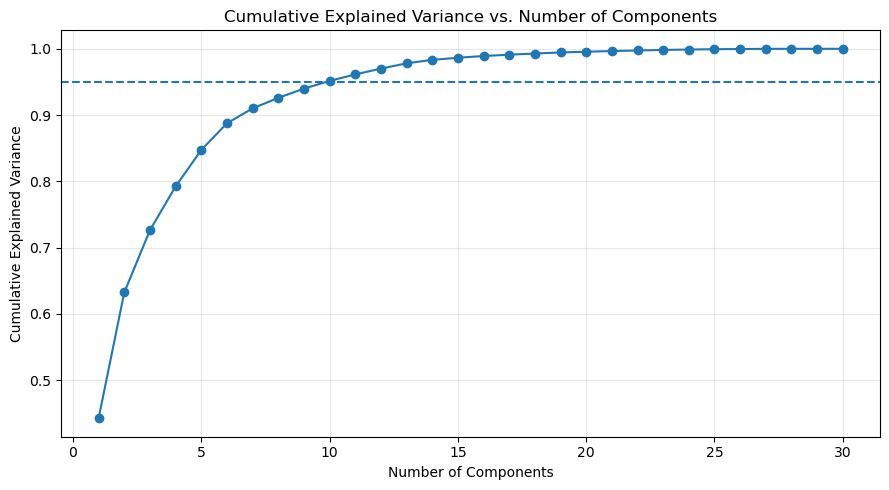

In [2]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the chart:** the curve climbs steeply for the first several components and then bends into a much flatter slope, the same "diminishing returns" shape that showed up in the elbow method for K-Means, only here it is tracking retained information rather than clustering cost. The dashed horizontal line marks the 95% variance threshold. Wherever the curve first crosses that line marks the number of components needed to keep the great majority of the dataset's structure while dropping the rest.

## Step 3 — Choose the Number of Components (~95% Variance) and Justify It

The cumulative variance plot shows the shape of the trade-off, but choosing an actual cutoff needs a number, not just a visual impression. A common convention — and the one used throughout this lab — is to keep enough components to retain about 95% of the total variance. That threshold is a judgment call, not a law of nature: it balances the benefit of a much smaller feature space against the cost of losing a small amount of information.

This step finds the smallest number of components whose cumulative variance first reaches 95%, and states what was gained in exchange.

In [3]:
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Components needed to retain 95% variance: {n_components_95}")
print(f"Variance retained at that count: {cumulative_variance[n_components_95 - 1]:.4f}")
print(f"Reduction: {X.shape[1]} original features -> {n_components_95} components")
print(f"Dimensionality cut by {(1 - n_components_95 / X.shape[1]) * 100:.1f}%")

Components needed to retain 95% variance: 10
Variance retained at that count: 0.9516
Reduction: 30 original features -> 10 components
Dimensionality cut by 66.7%


**Interpreting the result:** roughly a third of the original 30 features' worth of information is enough to summarize the same amount of variance in around ten components. That is a meaningful compression — a downstream model trained on this reduced set trains faster, overfits less easily on redundant/correlated features, and is far easier to reason about, all while retaining 95% of the variance the full feature set contained. The justification for stopping at this count rather than continuing further is simple: past this point, each additional component buys back only a small sliver of variance, at the cost of one more dimension to carry.

## Step 4 — Reduce to 2 Components and Visualize

Ten components is efficient for modeling, but it is still not something a person can look at directly. To actually see the data's structure, PCA is refit with exactly two components — accepting a bigger drop in retained variance in exchange for a plot that a human eye can read. The known diagnosis labels (malignant vs. benign) are used only for coloring the resulting scatter plot, never for fitting PCA itself, which stays entirely unsupervised.

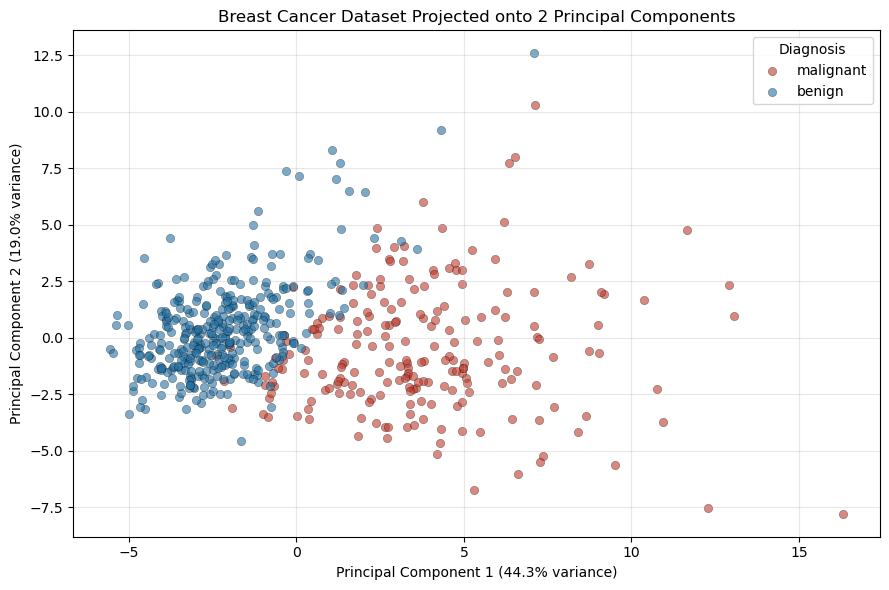

Variance retained by 2 components: 63.2%


In [4]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

variance_2d = pca_2d.explained_variance_ratio_

plt.figure(figsize=(9, 6))
colors = {"malignant": "#c0392b", "benign": "#2471a3"}
for label in y.unique():
    mask = y == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=label,
                alpha=0.6, c=colors[label], edgecolor="k", linewidth=0.3)

plt.xlabel(f"Principal Component 1 ({variance_2d[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({variance_2d[1]*100:.1f}% variance)")
plt.title("Breast Cancer Dataset Projected onto 2 Principal Components")
plt.legend(title="Diagnosis")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance retained by 2 components: {variance_2d.sum()*100:.1f}%")

**Reading the plot:** even though these two axes carry a modest fraction of the dataset's total variance compared to the ten-component version, they still separate malignant and benign samples into two visibly distinct regions with only moderate overlap. That separation is a strong signal that the 30 original measurements encode a real, dominant pattern related to diagnosis — and that PCA's first two directions happen to align closely with it. This is also the clearest illustration of PC axes losing direct interpretability: "Principal Component 1" is not any single original measurement, it is a weighted combination of many of them, which is the price paid for compressing 30 dimensions down to two.

## Step 5 — What the Reduction Preserved, and What It Cost

**What was preserved.** Reducing from 30 features to 10 components kept about 95% of the dataset's total variance, and even the far more aggressive reduction to 2 components preserved enough structure to visually separate malignant from benign samples without ever using the diagnosis label during fitting. The dominant sources of variation in the original 30 measurements — largely driven by cell size and shape irregularity — survived the compression essentially intact.

**What it cost.** Two things were given up. First, some variance was discarded outright: the 10-component version leaves about 5% of the total variance behind, and the 2-component version leaves considerably more, trading fidelity for the ability to plot the data at all. Second, and more importantly for future work, interpretability was lost. Each of the original 30 features had a concrete clinical meaning — radius, texture, concavity. Each principal component is instead a linear combination of many original features at once, so a component can no longer be pointed to and explained in plain clinical terms without additional analysis of its loadings.

**Takeaway.** PCA is well suited here as a compression and visualization tool, not as a replacement for the original features when interpretability matters. The 10-component version is a strong candidate to feed into a downstream classifier for Phase 3-style modeling; the 2-component version is best reserved for exploration and communication, exactly the same divide the program draws between PCA for modeling and t-SNE for pure visualization, which Day 4 will pick up next.